In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Dropout

import pickle


In [2]:
data=pd.read_csv('out time separated 2.csv')
data=data.sample(frac=1)
data = data[data['Successful_Read'] == True]
data = data[data['Shape'] == 'kare']

data

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Shape,...,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count,Folder,Successful_Read
93682,93682,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,kare,...,100.00,8.00,64.00,0.64,3000,cs,10,0,detektor data 2/ARNCO2/Kare/Kare 10x10/8x8/300...,True
53159,53159,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,kare,...,100.00,6.00,36.00,0.36,7500,cs,1,15,detektor data 2/P20/Kare/Kare 10x10/6x6/7500V Cs,True
62212,62212,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,kare,...,100.00,8.00,64.00,0.64,7500,kaynaksız,1,4,detektor data 2/P20/Kare/Kare 10x10/8x8/7500V ...,True
94311,94311,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,kare,...,100.00,8.00,64.00,0.64,3500,kaynaksız,1,0,detektor data 2/ARNCO2/Kare/Kare 10x10/8x8/350...,True
62473,62473,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,kare,...,100.00,8.00,64.00,0.64,3000,cs,3,0,detektor data 2/P20/Kare/Kare 10x10/8x8/3000V Cs,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91547,91547,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,kare,...,100.00,8.00,64.00,0.64,6500,cs,5,0,detektor data 2/ARNCO2/Kare/Kare 10x10/8x8/650...,True
14495,14495,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,kare,...,100.00,8.00,64.00,0.64,3500,cs,1,2,detektor data 2/P10/Kare/Kare 10x10/8x8/p10 35...,True
97828,97828,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,kare,...,45.97,4.78,22.85,0.50,6500,cs,1,2,"detektor data 2/ARNCO2/Kare/Kare 6,78X6,78/4,7...",True
20682,20682,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,kare,...,45.97,6.68,44.62,0.97,3500,cs,3,0,"detektor data 2/P10/Kare/Kare 6,78X6,78/6,68x6...",True


In [3]:

data.drop(['Shape','Folder','Successful_Read'],axis=1,inplace=True)
data = data[data['Time_Window'].isin([15])]

In [4]:
data["Peak_Count"].describe()

count    2456.000000
mean      103.118893
std       183.046622
min         0.000000
25%         0.000000
50%        34.000000
75%       146.000000
max      1975.000000
Name: Peak_Count, dtype: float64

<Axes: >

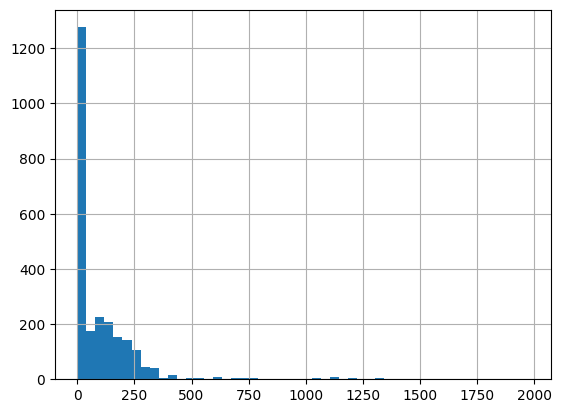

In [5]:
data["Peak_Count"].hist(bins = 50)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2456 entries, 66085 to 61363
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        2456 non-null   int64  
 1   Gas_Type          2456 non-null   object 
 2   CH4               2456 non-null   float64
 3   Ar                2456 non-null   float64
 4   N2                2456 non-null   float64
 5   CO2               2456 non-null   float64
 6   C                 2456 non-null   float64
 7   O                 2456 non-null   float64
 8   H                 2456 non-null   float64
 9   Detector_Size     2456 non-null   float64
 10  Detector_Area     2456 non-null   float64
 11  Cover_Size        2456 non-null   float64
 12  Cover_Area        2456 non-null   float64
 13  Cover_Area_Ratio  2456 non-null   float64
 14  Voltage           2456 non-null   int64  
 15  Source            2456 non-null   object 
 16  Time_Window       2456 non-null   int64  


In [7]:
type=pd.get_dummies(data['Gas_Type'],dtype=float)
type

,arnco2,p10,p20
66085,0.0,0.0,1.0
90857,1.0,0.0,0.0
21463,0.0,1.0,0.0
57824,0.0,0.0,1.0
57347,0.0,0.0,1.0
...,...,...,...
86374,1.0,0.0,0.0
87789,1.0,0.0,0.0
96291,1.0,0.0,0.0
93929,1.0,0.0,0.0


In [8]:
source=pd.get_dummies(data['Source'],dtype=float)
source

,cs,kaynaksız
66085,1.0,0.0
90857,0.0,1.0
21463,0.0,1.0
57824,1.0,0.0
57347,0.0,1.0
...,...,...
86374,0.0,1.0
87789,0.0,1.0
96291,1.0,0.0
93929,1.0,0.0


In [9]:
data=pd.concat([data,source],axis=1)
data

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count,cs,kaynaksız
66085,66085,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,2000,cs,15,0,1.0,0.0
90857,90857,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,4000,kaynaksız,15,0,0.0,1.0
21463,21463,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,2000,kaynaksız,15,0,0.0,1.0
57824,57824,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,4.00,16.00,0.16,7500,cs,15,205,1.0,0.0
57347,57347,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,4.00,16.00,0.16,6000,kaynaksız,15,68,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86374,86374,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,6.00,36.00,0.36,7500,kaynaksız,15,6,0.0,1.0
87789,87789,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,4.00,16.00,0.16,6500,kaynaksız,15,1,0.0,1.0
96291,96291,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,8000,cs,15,22,1.0,0.0
93929,93929,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,7500,cs,15,21,1.0,0.0


In [10]:
data[['Time_Window','Peak_Count','Voltage']] = data[['Time_Window','Peak_Count','Voltage']].astype('float')
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2456 entries, 66085 to 61363
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        2456 non-null   int64  
 1   Gas_Type          2456 non-null   object 
 2   CH4               2456 non-null   float64
 3   Ar                2456 non-null   float64
 4   N2                2456 non-null   float64
 5   CO2               2456 non-null   float64
 6   C                 2456 non-null   float64
 7   O                 2456 non-null   float64
 8   H                 2456 non-null   float64
 9   Detector_Size     2456 non-null   float64
 10  Detector_Area     2456 non-null   float64
 11  Cover_Size        2456 non-null   float64
 12  Cover_Area        2456 non-null   float64
 13  Cover_Area_Ratio  2456 non-null   float64
 14  Voltage           2456 non-null   float64
 15  Source            2456 non-null   object 
 16  Time_Window       2456 non-null   float64


In [11]:
data.drop(['Source','kaynaksız','Gas_Type','Unnamed: 0'],axis=1,inplace=True)
data['Peak_Count'] = np.sqrt(data['Peak_Count'])
data.head()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,Peak_Count,cs
66085,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,2000.0,15.0,0.000000,1.0
90857,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,4000.0,15.0,0.000000,0.0
21463,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,2000.0,15.0,0.000000,0.0
57824,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,4.00,16.00,0.16,7500.0,15.0,14.317821,1.0
57347,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,4.00,16.00,0.16,6000.0,15.0,8.246211,0.0


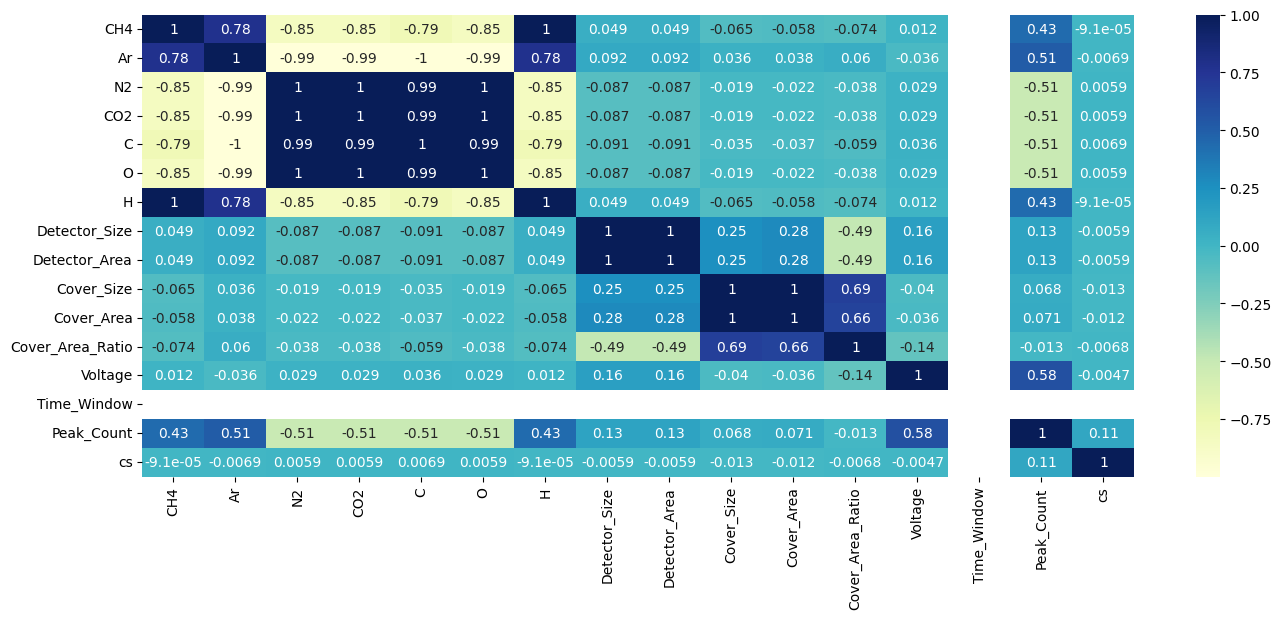

In [12]:
# creation of correlation matrix
corrM = data.corr()
plt.figure(figsize=(16, 6))

dataplot = sns.heatmap(corrM, cmap="YlGnBu", annot=True) 

In [13]:
x=data.drop(['Peak_Count'],axis=1)
x.head()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,cs
66085,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,2000.0,15.0,1.0
90857,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,4000.0,15.0,0.0
21463,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,2000.0,15.0,0.0
57824,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,4.00,16.00,0.16,7500.0,15.0,1.0
57347,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,4.00,16.00,0.16,6000.0,15.0,0.0


In [14]:
y=data['Peak_Count']
y

66085     0.000000
90857     0.000000
21463     0.000000
57824    14.317821
57347     8.246211
           ...    
86374     2.449490
87789     1.000000
96291     4.690416
93929     4.582576
61363    14.696938
Name: Peak_Count, Length: 2456, dtype: float64

In [15]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [16]:
X_train.shape, X_test.shape

((1964, 15), (492, 15))

In [17]:
scaler = preprocessing.MinMaxScaler()

In [18]:
scaler.fit(X_train)

MinMaxScaler()

In [19]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)


In [20]:
from tensorflow.keras.optimizers import Adam

In [21]:
model = Sequential([
    InputLayer(input_shape=X_train.shape[1]),
    Dense(256,activation='relu'),
    Dropout(0.4),
    Dense(128,activation='relu'),
    Dropout(0.4),
    Dense(1,activation='relu'),
])
model.compile(optimizer = Adam(learning_rate=0.001),loss='mae')

In [22]:
model.fit(X_train,y_train,epochs=250,batch_size=128,validation_data=(X_test,y_test))

Epoch 1/250
16/16 [==============================] - 1s 21ms/step - loss: 6.5449 - val_loss: 5.8952
Epoch 2/250
16/16 [==============================] - 0s 7ms/step - loss: 4.7987 - val_loss: 3.9175
Epoch 3/250
16/16 [==============================] - 0s 8ms/step - loss: 3.9342 - val_loss: 3.6825
Epoch 4/250
16/16 [==============================] - 0s 7ms/step - loss: 3.6648 - val_loss: 3.2032
Epoch 5/250
16/16 [==============================] - 0s 8ms/step - loss: 3.2419 - val_loss: 2.6487
Epoch 6/250
16/16 [==============================] - 0s 6ms/step - loss: 2.9338 - val_loss: 2.3739
Epoch 7/250
16/16 [==============================] - 0s 7ms/step - loss: 2.6676 - val_loss: 2.1657
Epoch 8/250
16/16 [==============================] - 0s 7ms/step - loss: 2.5336 - val_loss: 2.0618
Epoch 9/250
16/16 [==============================] - 0s 7ms/step - loss: 2.4128 - val_loss: 2.0203
Epoch 10/250
16/16 [==============================] - 0s 10ms/step - loss: 2.3415 - val_loss: 1.9762
Epoch 1

In [23]:
pred = model.predict(X_test)

16/16 [==============================] - 0s 2ms/step


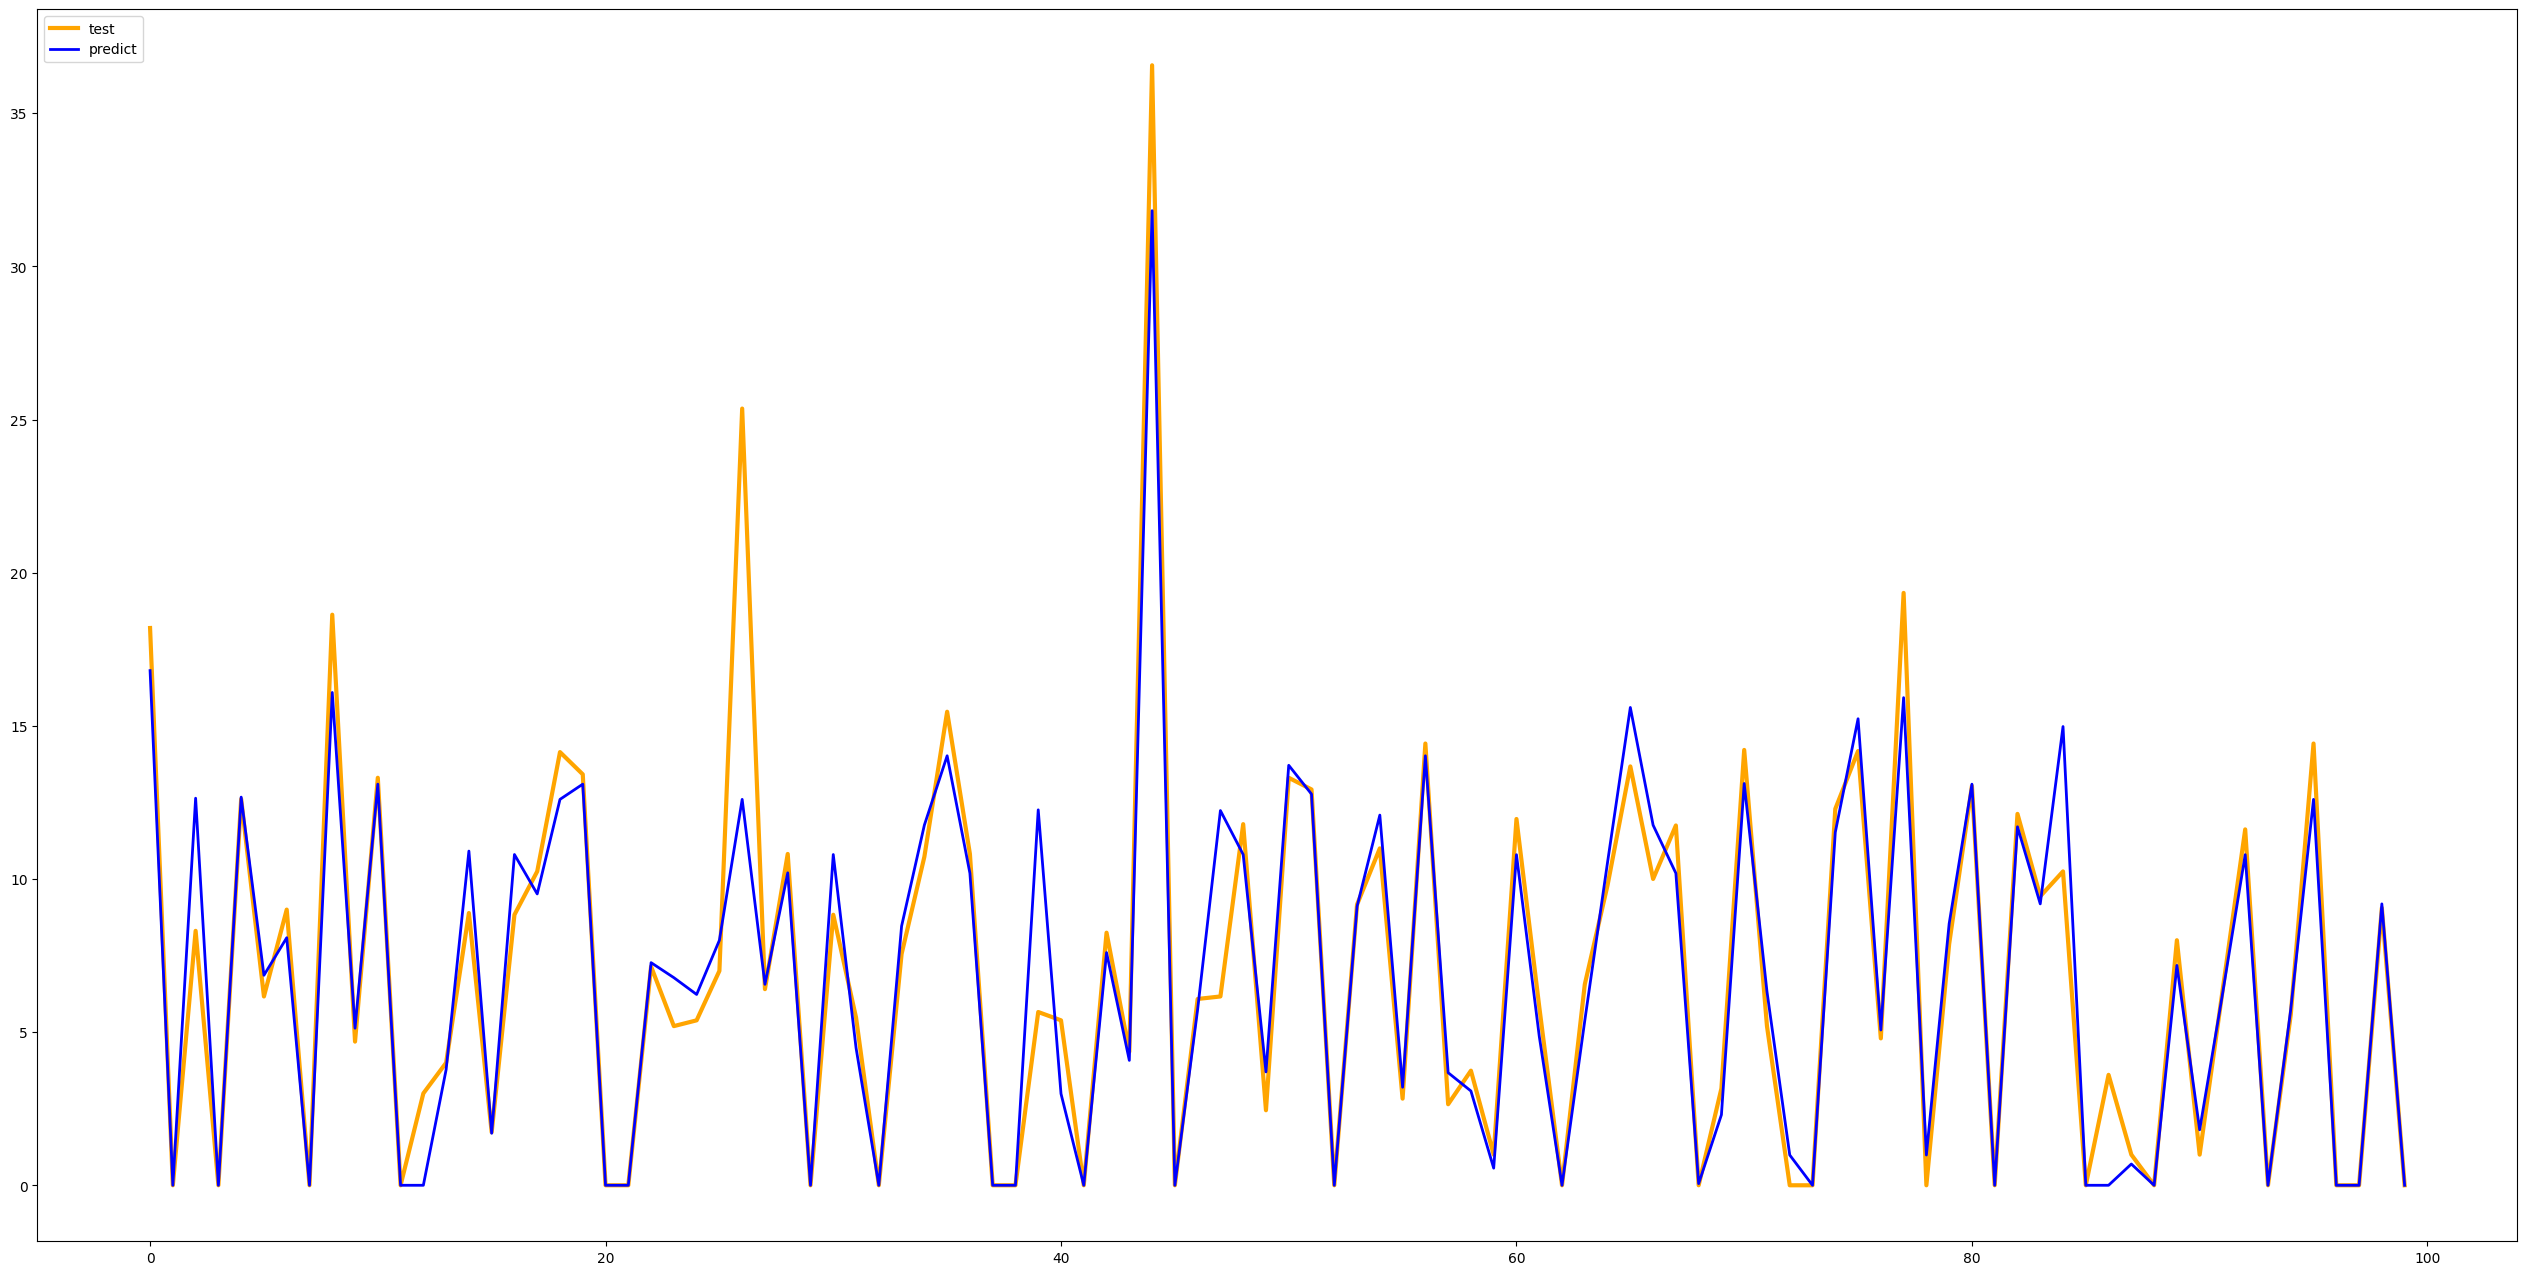

In [24]:
plt.figure(figsize=(32, 16))
plt.plot(range(0,len(X_test))[:100],y_test[:100], color="orange", linewidth=3 ,label = 'test')
plt.plot(range(0,len(X_test))[:100],pred[:100], color="blue", linewidth=2,label = 'predict')
plt.legend(loc="upper left")
plt.show()

In [25]:
metrics.r2_score(y_test, pred)

0.8552793480339911

<Axes: >

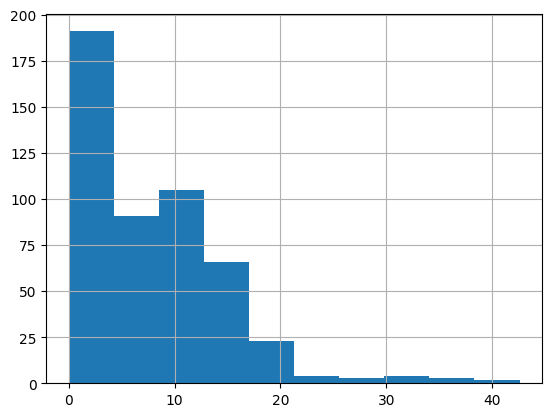

In [26]:
y_test.hist(bins=10)